In [ ]:
import os
import sys
import cv2
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "./.."))
sys.path.append(PROJECT_ROOT)
from app.modelsAI.insightFace.model import cosine_sim, app
from app.modelsAI.unet.segmentaion import segment_face
import matplotlib.pyplot as plt
from app.utils.cropImage import cropImage
import xml.etree.ElementTree as ET

def parse_voc_xml(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    boxes = []
    for obj in root.findall("object"):
        bnd = obj.find("bndbox")
        xmin = int(bnd.find("xmin").text)
        ymin = int(bnd.find("ymin").text)
        xmax = int(bnd.find("xmax").text)
        ymax = int(bnd.find("ymax").text)
        boxes.append((xmin, ymin, xmax, ymax))
    return boxes
def iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    inter = max(0, xB - xA) * max(0, yB - yA)
    areaA = (boxA[2]-boxA[0])*(boxA[3]-boxA[1])
    areaB = (boxB[2]-boxB[0])*(boxB[3]-boxB[1])
    union = areaA + areaB - inter

    return inter / union if union > 0 else 0

imagesTest = r"/Users/macos/Mon Hoc/nam 3/kì 1/Computer vision/SmartCamera SecuritySystem/dataset/tesst/images"
labelsTest = r"/Users/macos/Mon Hoc/nam 3/kì 1/Computer vision/SmartCamera SecuritySystem/dataset/tesst/annotations"
print(len(os.listdir(imagesTest)))
IOU_THRESHOLD = 0.5
TP = 0
FP = 0
FN = 0
TotalFace = 0

y_true = []
y_score = []

for name in os.listdir(imagesTest):

    if not name.lower().endswith(".png"):
        continue

    img_path = os.path.join(imagesTest, name)
    xml_path = os.path.join(labelsTest, name.replace(".png", ".xml"))

    img = cv2.imread(img_path)
    if img is None or not os.path.exists(xml_path):
        continue

    gt_boxes = parse_voc_xml(xml_path)
    faces = app.get(img)
    TotalFace += len(faces)
    pred_boxes = [(tuple(map(int, f.bbox)), f.det_score) for f in faces]
    matched_gt = set()

    # ---- match prediction với ground truth ----
    for pb, score in pred_boxes:
        matched = False
        for i, gb in enumerate(gt_boxes):
            if i in matched_gt:
                continue
            if iou(pb, gb) >= IOU_THRESHOLD:
                TP += 1
                matched_gt.add(i)
                matched = True
                break

        if matched:
            y_true.append(1)
        else:
            FP += 1
            y_true.append(0)

        y_score.append(score)

    FN += len(gt_boxes) - len(matched_gt)


/Users/macos/Mon Hoc/nam 3/kì 1/Computer vision/SmartCamera SecuritySystem/venv/lib/python3.11/site-packages/insightface/utils/face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


[UNet] Model loaded successfully from /Users/macos/Mon Hoc/nam 3/kì 1/Computer vision/SmartCamera SecuritySystem/app/modelsAI/unet/model.pth


error: OpenCV(4.12.0) :-1: error: (-5:Bad argument) in function 'resize'
> Overload resolution failed:
>  - src is not a numpy array, neither a scalar
>  - Expected Ptr<cv::UMat> for argument 'src'


<Figure size 1800x2500 with 0 Axes>

mAP@0.5: 1.0000
Precision: 0.8610
Recall: 0.8227
F1-score: 0.8414


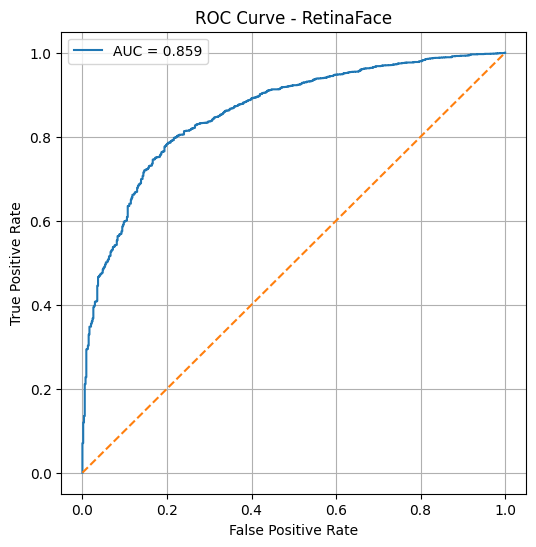

In [32]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np
precision, recall, _ = precision_recall_curve(y_true, y_score)

precision = np.maximum.accumulate(precision[::-1])[::-1]

ap = auc(recall, precision)

precision = TP / (TP + FP + 1e-6)
recall    = TP / (TP + FN + 1e-6)
f1        = 2 * precision * recall / (precision + recall + 1e-6)
print(f"mAP@0.5: {ap:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - RetinaFace")
plt.legend()
plt.grid(True)
plt.show()